# Coursework Assessment: Question 4
---

## Q4(a) - Analytic Proof
The given ordinary differential equation (ODE) is:
$$\frac{dy}{dt} = -\alpha(y - \cos(t)) - \sin(t)$$

We need to show that $y(t) = \cos(t)$ is the exact solution.
First, we find the derivative of the proposed solution with respect to $t$:
$$\frac{dy}{dt} = -\sin(t)$$

Next, we substitute $y(t) = \cos(t)$ into the right-hand side (RHS) of the original ODE:
$$\text{RHS} = -\alpha(\cos(t) - \cos(t)) - \sin(t)$$
$$\text{RHS} = -\alpha(0) - \sin(t) = -\sin(t)$$

Since the Left-Hand Side (LHS) equals the Right-Hand Side (RHS), $y(t) = \cos(t)$ is indeed the exact analytical solution to the ODE.

---
## Q4(b) - RK4 Method for stiff ODE 

### 4th-order Runge-Kutta method

ODE solvers:
$$ m_1 = f(t_k, y_k) $$
$$ m_2 = f(t_k + \frac{h}{2}, y_k+\frac{h}{2} m_1) $$
$$ m_3 = f(t_k + \frac{h}{2}, y_k+\frac{h}{2} m_2) $$
$$ m_4 = f(t_k + \frac{h}{2}, y_k+\frac{h}{2} m_3) $$

Use all four to calculate $y_{k+1}$
$$ y_{k+1} = y_k + \frac{h}{6}(m_1 + 2m_2 + 2m_3 + m_4) $$

<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
/var/folders/3l/gcmv93g129dfkprq8_7b9gt80000gn/T/ipykernel_12849/2666218249.py:44: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_num, y_num, '-o', label=f'h = $\pi$/{int(np.pi/h)}')


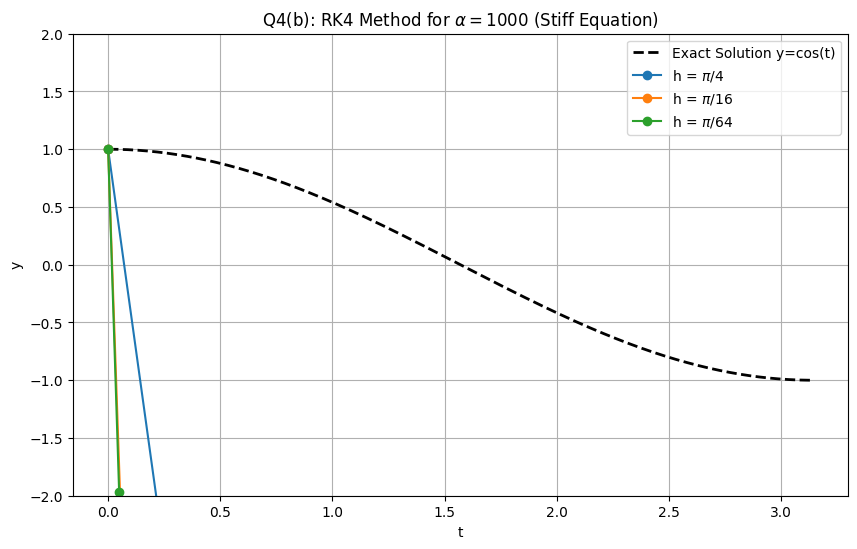

To get a qualitatively correct solution for alpha=1000, we need n = 11
Step size required: h = pi / 2^11


In [15]:
# ==================== Q4(b) ====================

import numpy as np
import matplotlib.pyplot as plt

# 1. Define Function f(t, y)
def f_ode(t, y, alpha):
    return -alpha * (y - np.cos(t)) - np.sin(t)

# 2. Define RK4 Algorithm
def myRK4(f, t0, y0, t_end, h, alpha):
    t_values = np.arange(t0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y0
    
    for i in range(len(t_values) - 1):
        t_i = t_values[i]
        y_i = y_values[i]
        
        k1 = f(t_i, y_i, alpha)
        k2 = f(t_i + h/2, y_i + h/2 * k1, alpha)
        k3 = f(t_i + h/2, y_i + h/2 * k2, alpha)
        k4 = f(t_i + h, y_i + h * k3, alpha)
        
        # Avoiding (Overflow)
        y_next = y_i + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        y_values[i+1] = np.clip(y_next, -10, 10) # Plotting Limit
        
    return t_values, y_values

# 3. Parameters Setting
alpha_b = 1000
t_start, t_end = 0, np.pi
y0 = 1.0
stepsizes = [np.pi/4, np.pi/16, np.pi/64]

# 4. Plotting
plt.figure(figsize=(10, 6))
t_exact = np.linspace(t_start, t_end, 500)
plt.plot(t_exact, np.cos(t_exact), 'k--', label='Exact Solution y=cos(t)', linewidth=2)

for h in stepsizes:
    t_num, y_num = myRK4(f_ode, t_start, y0, t_end, h, alpha_b)
    plt.plot(t_num, y_num, '-o', label=f'h = $\pi$/{int(np.pi/h)}')

plt.title(r'Q4(b): RK4 Method for $\alpha=1000$ (Stiff Equation)')
plt.xlabel('t')
plt.ylabel('y')
plt.ylim(-2, 2)
plt.legend()
plt.grid(True)
plt.show()

# 5. Finding Minimum n for Qualitatively Correct Solution
for n in range(6, 14):
    h_test = np.pi / (2**n)
    t_num, y_num = myRK4(f_ode, t_start, y0, t_end, h_test, alpha_b)
    
    max_error = np.max(np.abs(y_num - np.cos(t_num)))
    if max_error < 0.1:
        print(f"To get a qualitatively correct solution for alpha=1000, we need n = {n}")
        print(f"Step size required: h = pi / 2^{n}")
        break

### Explanation

The ODE has exact solution $y(t)=\cos t$, but when $\alpha=1000$ the equation contains a decaying error mode. The error satisfies
$$ e'(t)=-\alpha e(t), $$
so any numerical error decays very rapidly in the true solution.

However, the RK4 method is explicit and has a limited stability region. 

For stability, $h\lambda$ is needed to lie inside this region. With $\lambda=-1000$, this requires roughly $h \lesssim 2.8\times10^{-3}$.

The step sizes $h=\pi/4$, $h=\pi/16$, and $h=\pi/64$ are all much larger than this stability limit, so the numerical solution becomes unstable and oscillates, instead of following $\cos t$. Only when $h=\pi/2^n$ is small enough (around $n\approx11$) does the RK4 method produce a qualitatively correct solution.

This shows that RK4 performs poorly for stiff ODEs unless the step size is extremely small.


---
## Q4(c) - Trapezoid Method and Error Analysis

<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\p'
/var/folders/3l/gcmv93g129dfkprq8_7b9gt80000gn/T/ipykernel_12849/528035852.py:34: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_num, y_num, '-o', label=f'h = $\pi$/{int(np.pi/h)}')
/var/folders/3l/gcmv93g129dfkprq8_7b9gt80000gn/T/ipykernel_12849/528035852.py:59: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Absolute Error at t=$\pi$')


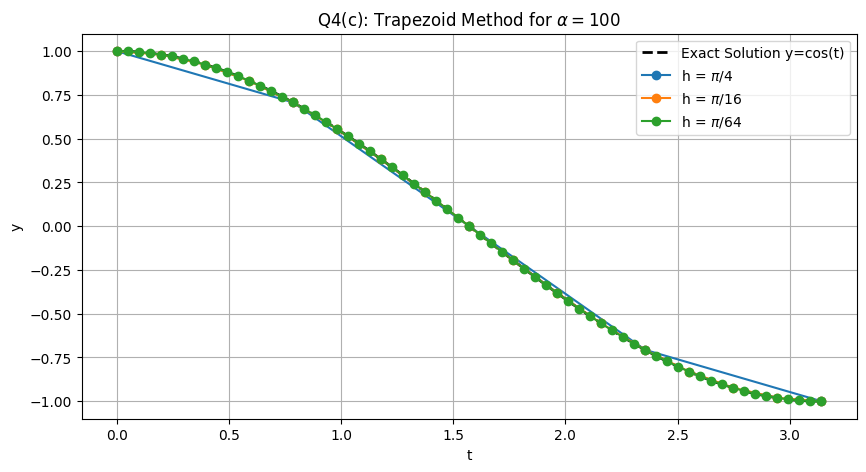

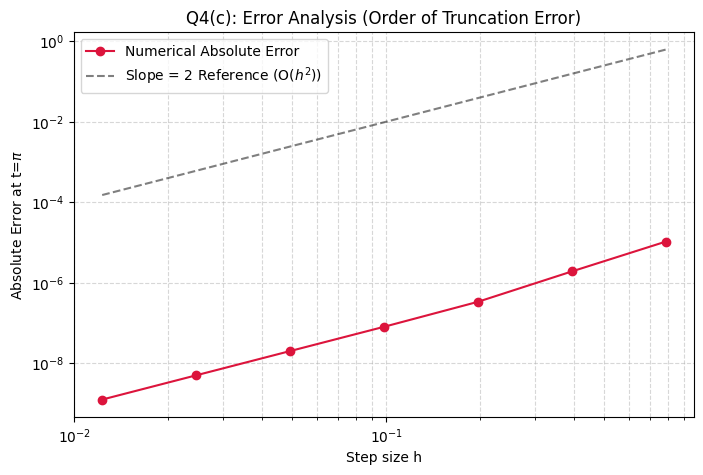

In [16]:
# ==================== Q4(c) ====================
import numpy as np
import matplotlib.pyplot as plt

alpha_c = 100
t_start, t_end = 0, np.pi
y0 = 1.0

# 1. Define Trapezoid Method Step
def trapezoid_step(yk, tk, tk_next, h, alpha):
    # f(tk, yk) = -alpha * (yk - cos(tk)) - sin(tk)
    f_k = -alpha * (yk - np.cos(tk)) - np.sin(tk)
    numerator = yk + (h/2) * (f_k + alpha * np.cos(tk_next) - np.sin(tk_next))
    denominator = 1 + (alpha * h / 2)
    return numerator / denominator

def solve_trapezoid(alpha, h):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y0
    for k in range(len(t_values) - 1):
        y_values[k+1] = trapezoid_step(y_values[k], t_values[k], t_values[k+1], h, alpha)
    return t_values, y_values

# 2. Plotting Trapezoid Method Solutions
stepsizes = [np.pi/4, np.pi/16, np.pi/64]

plt.figure(figsize=(10, 5))
t_exact = np.linspace(t_start, t_end, 500)
plt.plot(t_exact, np.cos(t_exact), 'k--', label='Exact Solution y=cos(t)', linewidth=2)

for h in stepsizes:
    t_num, y_num = solve_trapezoid(alpha_c, h)
    plt.plot(t_num, y_num, '-o', label=f'h = $\pi$/{int(np.pi/h)}')

plt.title(r'Q4(c): Trapezoid Method for $\alpha=100$')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 3. Error Analysis for Trapezoid Method (log-log plot)
h_list = [np.pi / (2**n) for n in range(2, 9)]
errors = []

for h in h_list:
    t_num, y_num = solve_trapezoid(alpha_c, h)
    # Calculate absolute error at t = pi
    final_error = abs(y_num[-1] - np.cos(t_end)) 
    errors.append(final_error)

# Plotting
plt.figure(figsize=(8, 5))
plt.loglog(h_list, errors, 'o-', color='crimson', label='Numerical Absolute Error')
plt.loglog(h_list, [h**2 for h in h_list], 'k--', alpha=0.5, label='Slope = 2 Reference (O($h^2$))')

plt.xlabel('Step size h')
plt.ylabel('Absolute Error at t=$\pi$')
plt.title('Q4(c): Error Analysis (Order of Truncation Error)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

---
## Q4(d) Strengths and Weaknesses of RK4 and Trapezoid Methods
Based on the results from (b) and (c):
- 4th Order Runge-Kutta (RK4):

  $Strengths:$ It is a 4th-order method, meaning it has a very high local accuracy for non-stiff problems. It is explicit, making it easy to implement without solving algebraic equations.
  
  $Weaknesses:$ It performs poorly on stiff ODEs (like when $\alpha=1000$). The stability region is limited, causing the numerical solution to oscillate wildly and explode unless an extremely small step size ($h$) is used, which is computationally expensive.

- Trapezoid Method:

  $Strengths:$ It is an implicit method and possesses A-stability, meaning it remains numerically stable even for stiff equations with large step sizes (as seen when $\alpha=100$). 
  
  $Weaknesses:$ It is only a 2nd-order method, so its local accuracy is lower than RK4. Being implicit, it generally requires solving a non-linear algebraic equation at each step (though in our specific case, the ODE was linear in $y$, allowing us to algebraically derive an explicit formula).

---
## Q4(e) - SIS Model

Condition 1 (Initial I=0.1) reached steady state at t ≈ 918.92
Condition 2 (Initial I=0.9) reached steady state at t ≈ 580.58


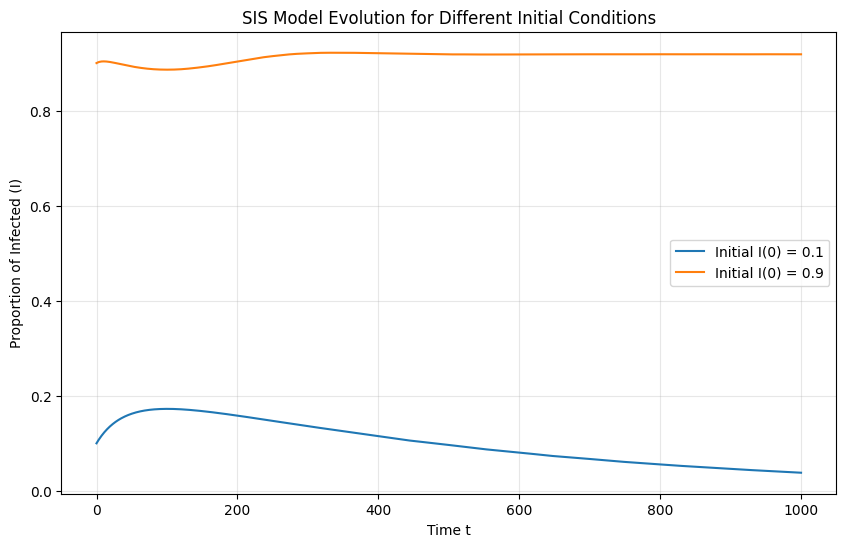

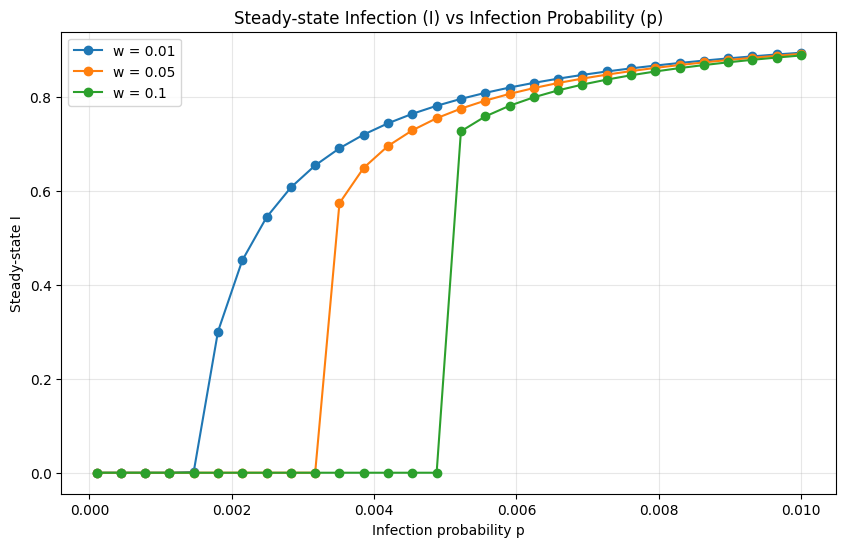

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define SIS Model ODEs
def sis_model(t, y, p, r, w, k_hat):
    I, Lii, Lss = y
    
    # Checking bounds for I and S
    I = min(max(I, 0), 1)
    S = max(1 - I, 1e-10) 
    
    # Calculating Lsi based on the total link density constraint
    Lsi = k_hat - Lii - Lss
    Lsi = max(Lsi, 0)
    
    # ODEs
    dI_dt = p * Lsi - r * I
    dLii_dt = p * Lsi * (Lsi / S + 1) - 2 * r * Lii
    dLss_dt = (r + w) * Lsi - (2 * p * Lsi * Lss) / S
    return [dI_dt, dLii_dt, dLss_dt]

# Parameters Setting
r_val = 0.002
k_hat_val = 10
t_span = (0, 1000)
t_eval = np.linspace(0, 1000, 1000)

# 1. Evolution for Different Initial Conditions
p_val = 0.0015
w_val = 0.05
initial_conditions = [
    (0.1, 0.1, 8.1),
    (0.9, 8.1, 0.1)
]

plt.figure(figsize=(10, 6))
for i, y0 in enumerate(initial_conditions):
    sol = solve_ivp(sis_model, t_span, y0, args=(p_val, r_val, w_val, k_hat_val), t_eval=t_eval)
    plt.plot(sol.t, sol.y[0], label=f'Initial I(0) = {y0[0]}')
    
    # Calculate the derivatives at each time point to check for steady state
    for idx in range(len(sol.t)):
        dy = sis_model(sol.t[idx], sol.y[:, idx], p_val, r_val, w_val, k_hat_val)
        # Checking steady state condition
        if np.all(np.abs(dy) < 1e-4):
            print(f"Condition {i+1} (Initial I={y0[0]}) reached steady state at t ≈ {sol.t[idx]:.2f}")
            break

plt.title('SIS Model Evolution for Different Initial Conditions')
plt.xlabel('Time t')
plt.ylabel('Proportion of Infected (I)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Steady-state Infection vs Infection Probability
p_range = np.linspace(0.0001, 0.01, 30)
w_list = [0.01, 0.05, 0.1]
r_fixed = 0.02 

plt.figure(figsize=(10, 6))
for w_val in w_list:
    steady_states = []
    for p_temp in p_range:
        res = solve_ivp(sis_model, (0, 5000), [0.1, 0.1, 8.1], 
                        args=(p_temp, r_fixed, w_val, k_hat_val))
        steady_states.append(res.y[0, -1])
    plt.plot(p_range, steady_states, '-o', label=f'w = {w_val}')

plt.title('Steady-state Infection (I) vs Infection Probability (p)')
plt.xlabel('Infection probability p')
plt.ylabel('Steady-state I')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Explanation 

As $p$ increases, the steady-state level of infection increases because transmission becomes stronger relative to recovery. 

As $w$ increases, the steady-state infection decreases and the epidemic threshold shifts to larger $p$, because susceptibles rewire away from infecteds, reducing SI links and limiting spread. 

So that the results show the balance between disease transmission and adaptive network rewiring.

---
## Q4(f) - Result Expection
The equation-based model and agent-based model should show similar overall trends, such as whether infection persists or dies out. 

However, the equation-based model is deterministic and averaged, giving smooth results, while the agent-based model is stochastic, so different runs may produce different outcomes.

The equation-based model is faster and easier to analyse but may oversimplify interactions. 

The agent-based model is more realistic because it simulates individual behaviour and randomness, but it is computationally more expensive and harder to analyse.
